## **Phase 2 Training Model ST - DBSCAN**

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from kneed import KneeLocator
from DBCV import DBCV
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ── ST-DBSCAN library ──────────────────────────────────────────────
# ชี้ไปที่ โฟลเดอร์ ที่มี st_dbscan_lib.py 
PATH_STDBSCAN_DIR = r"D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final"

# ── Import ST-DBSCAN ──────────────────────────────────────────────
sys.path.insert(0, PATH_STDBSCAN_DIR)   # เพิ่มโฟลเดอร์เข้า sys.path
from st_dbscan_lib import ST_DBSCAN

In [4]:
# ══════════════════════════════════════════════════════════════════
#  กำหนด Path ทั้งหมดในเซลล์นี้ที่เดียว
# ══════════════════════════════════════════════════════════════════

BASE_PATH = r"D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final"

# ── Input / Output ─────────────────────────────────────────────────
PATH_INPUT       = r"D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final\phase 1\hotspot_final.gpkg"
PATH_OUTPUT      = os.path.join(BASE_PATH, "hotspot_clustered_final.gpkg")

# ── Land use (สำหรับวิเคราะห์ขนาดแปลง EPS reference) ──────────────
PATH_LANDUSE_SHP = r"D:\gistnu\Data\Landuse_พิษณุโลก_2564\LU_PLK_2564.shp"

# ── Output directory ──────────────────────────────────────────────
PLOT_DIR = os.path.join(BASE_PATH, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

assert os.path.exists(PATH_INPUT), f"✗ ไม่พบไฟล์: {PATH_INPUT}"
print(f"✓ BASE_PATH       : {BASE_PATH}")
print(f"✓ PATH_INPUT      : {PATH_INPUT}")
print(f"✓ PATH_OUTPUT     : {PATH_OUTPUT}")
print(f"✓ import ST_DBSCAN สำเร็จ")


✓ BASE_PATH       : D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final
✓ PATH_INPUT      : D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final\phase 1\hotspot_final.gpkg
✓ PATH_OUTPUT     : D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final\hotspot_clustered_final.gpkg
✓ import ST_DBSCAN สำเร็จ


In [5]:
# CELL 2 — โหลดข้อมูลจาก Phase 1
gdf = gpd.read_file(PATH_INPUT)
print(f"โหลดสำเร็จ: {len(gdf):,} แถว | {len(gdf.columns)} columns")
print(f"CRS: {gdf.crs}")

โหลดสำเร็จ: 2,458 แถว | 27 columns
CRS: EPSG:32647


In [6]:
# --- CHECKPOINT 2 ---
assert len(gdf) > 0,                        "✗ ไม่มีข้อมูล"
assert 'x_utm'          in gdf.columns,     "✗ ไม่มี x_utm"
assert 'y_utm'          in gdf.columns,     "✗ ไม่มี y_utm"
assert 't_days'         in gdf.columns,     "✗ ไม่มี t_days"
assert 'fire_type'      in gdf.columns,     "✗ ไม่มี fire_type"
assert 'dist_agri_m'    in gdf.columns,     "✗ ไม่มี dist_agri_m"
assert 'dist_forest_m'  in gdf.columns,     "✗ ไม่มี dist_forest_m"
assert gdf['x_utm'].notna().all(),           "✗ x_utm มี null"
assert gdf['y_utm'].notna().all(),           "✗ y_utm มี null"
assert gdf['t_days'].notna().all(),          "✗ t_days มี null"
print('✓ ตรวจสอบ input ผ่านทุกรายการ')
print(f'✓ fire_type: {gdf["fire_type"].value_counts().to_dict()}')
print(f'✓ columns: {len(gdf.columns)} columns')
# ตรวจ daynight columns ที่ต้องมาจาก Phase 1
for col in ('daynight_label', 'is_day'):
    assert col in gdf.columns, f"✗ ไม่มี column {col} — ตรวจสอบ Phase 1 export"
print("✓ daynight_label และ is_day พร้อมใช้งาน")


✓ ตรวจสอบ input ผ่านทุกรายการ
✓ fire_type: {'agricultural': 2108, 'other': 221, 'forest': 129}
✓ columns: 27 columns
✓ daynight_label และ is_day พร้อมใช้งาน


In [7]:
gdf['year'] = pd.to_datetime(gdf['acq_date']).dt.year
print(gdf['year'].value_counts().sort_index().to_string())
print(f"\nเฉลี่ยต่อปี: {len(gdf)/gdf['year'].nunique():.0f} จุด")
print(f"เฉลี่ยต่อเดือน: {len(gdf)/(gdf['year'].nunique()*12):.0f} จุด")

year
2020    846
2021    525
2022    362
2023    343
2024    145
2025    185
2026     52

เฉลี่ยต่อปี: 351 จุด
เฉลี่ยต่อเดือน: 29 จุด


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  กำหนด Parameter สุดท้าย แยกตาม fire_type
#
#  เกณฑ์การเลือก (4 ข้อร่วมกัน):
#    1) DBCV สูง
#    2) avg_years_per_cluster ≈ 1.0  →  cluster อยู่ในปีเดียว (เหตุการณ์จริง)
#    3) avg_days_per_cluster สมเหตุสมผลเชิงกายภาพ (ไม่ยาวข้ามฤดู)
#    4) n_cluster มากพอให้วิเคราะห์พฤติกรรมได้
#
#  ──────────────────────────────────────────────────────────────────────────
#  ▶ วิธีเพิ่ม fire_type ใหม่ (เช่น 'other' หรือ 'grassland'):
#
#  ขั้นที่ 1 — เพิ่ม entry ใน params ด้านล่าง:
#    'other': {'eps1': 1500, 'eps2': 10, 'min_pts': 4},
#    (ค่าเริ่มต้น: ดู Kneedle + EPS reference ใน Cell ถัดไป แล้วยืนยันด้วย grid search)
#
#  ขั้นที่ 2 — เพิ่ม entry ใน param_justification:
#    'other': 'DBCV ... | n_cluster=... | เหตุผล ...',
#
#  ขั้นที่ 3 — เพิ่ม fire_type ใน grid dict (Cell Grid Search):
#    'other': {'eps1': [500, 1000, 1500], 'eps2': [5, 7, 10], 'min_pts': [3, 4]},
#
#  ขั้นที่ 4 — เพิ่มสีใน palette (Cell Visualize):
#    palette['other'] = 'orange'
#
#  ⚠ ข้อควรระวัง:
#  - sigma_xy และ sigma_t ถูก fit จากข้อมูลรวมทุก fire_type
#    → เมื่อเพิ่ม fire_type ใหม่ ตัวเลข sigma จะเปลี่ยน
#    → ต้องรัน grid search ใหม่ทุกประเภท ไม่ใช่แค่ประเภทที่เพิ่ม
#  - หาก fire_type ใหม่มีจุดน้อย (<50) ให้ผ่อน min_pts ลงเหลือ 2-3
#    และขยาย eps1/eps2 ให้กว้างขึ้นเพื่อให้ cluster ก่อตัวได้
#
#  ─────────────────────────────────────────────────────────────────────────
#  สาเหตุที่ 'other' ไม่ถูกนำเข้าวิเคราะห์ในงานวิจัยนี้:
#  'other' เป็นกลุ่ม heterogeneous รวมที่ดินหลายประเภท (ชุมชน/แม่น้ำ/ถนน)
#  ที่ไม่มีพฤติกรรมไฟร่วมกัน → clustering จะได้ผลเบี้ยว
#  แต่ยังรายงานจำนวนจุดไว้เพื่อความโปร่งใส
# ══════════════════════════════════════════════════════════════════════════════

MIN_PTS = 4   

params = {
    'agricultural': {'eps1': 1000, 'eps2': 7,  'min_pts': 4},
    'forest':       {'eps1': 1000, 'eps2': 14, 'min_pts': 3},
    # ── เพิ่ม fire_type ใหม่ตรงนี้ (ดูคำแนะนำด้านบน) ──────────────────
    # 'other':      {'eps1': 1500, 'eps2': 10, 'min_pts': 4},
}

print('=' * 78)
print('จำนวน hotspot แยกประเภท (ก่อนเข้า ST-DBSCAN)')
print('=' * 78)
for ft, cnt in gdf['fire_type'].value_counts().items():
    tag = '→ วิเคราะห์ ST-DBSCAN' if ft in params else '→ ไม่นำเข้าวิเคราะห์'
    print(f'  {ft:<14}: {cnt:>5} จุด  {tag}')


จำนวน hotspot แยกประเภท (ก่อนเข้า ST-DBSCAN)
  agricultural  :  2108 จุด  → วิเคราะห์ ST-DBSCAN
  other         :   221 จุด  → ไม่นำเข้าวิเคราะห์
  forest        :   129 จุด  → วิเคราะห์ ST-DBSCAN


In [9]:
# Scale spatial และ temporal
scaler_xy = StandardScaler()
scaler_t  = StandardScaler()

xy_scaled = scaler_xy.fit_transform(gdf[['x_utm', 'y_utm']])
t_scaled  = scaler_t.fit_transform(gdf[['t_days']])

sigma_xy  = scaler_xy.scale_[0]
sigma_t   = scaler_t.scale_[0]

print(f'σ_xy = {sigma_xy:.2f} m')
print(f'σ_t  = {sigma_t:.2f} วัน (t_days)')

X = np.hstack([xy_scaled, t_scaled])
print(f"X shape: {X.shape}")

σ_xy = 16108.85 m
σ_t  = 635.66 วัน (t_days)
X shape: (2458, 3)


In [10]:
# --- CHECKPOINT 3 ---
print("\n[CHECKPOINT 3] ตรวจสอบหลัง Scale")
assert X.shape == (len(gdf), 3),      "✗ shape ไม่ถูกต้อง"
assert not np.isnan(X).any(),         "✗ มี NaN"
assert not np.isinf(X).any(),         "✗ มี Inf"
means = X.mean(axis=0)
stds  = X.std(axis=0)
assert all(abs(means) < 0.01),        "✗ mean ไม่ใกล้ 0"
assert all(abs(stds - 1) < 0.01),     "✗ std ไม่ใกล้ 1"
print(f"✓ mean: {means.round(4)}")
print(f"✓ std : {stds.round(4)}")
print("✓ Scale ถูกต้อง mean≈0 std≈1")


[CHECKPOINT 3] ตรวจสอบหลัง Scale
✓ mean: [-0.  0.  0.]
✓ std : [1. 1. 1.]
✓ Scale ถูกต้อง mean≈0 std≈1


In [11]:
# CELL 4 — Kneedle หา EPS1 แยกตาม fire_type (ใช้เป็น reference)
for fire_type, p in params.items():
    gdf_ft = gdf[gdf['fire_type'] == fire_type].copy()
    if len(gdf_ft) < 10:
        continue

    xy_ft = scaler_xy.transform(gdf_ft[['x_utm', 'y_utm']])
    t_ft  = scaler_t.transform(gdf_ft[['t_days']])
    X_ft  = np.hstack([xy_ft, t_ft])

    nbrs     = NearestNeighbors(n_neighbors=MIN_PTS, metric='euclidean').fit(X_ft)
    dists, _ = nbrs.kneighbors(X_ft)
    k_dist   = np.sort(dists[:, MIN_PTS-1])[::-1]

    kneedle       = KneeLocator(range(len(k_dist)), k_dist, S=1.0, curve='convex', direction='decreasing')
    elbow_val     = k_dist[kneedle.knee] if kneedle.knee else k_dist[0]
    eps1_suggested = elbow_val * sigma_xy

    doy_sorted   = np.sort(gdf_ft['t_days'].values)
    doy_diffs    = np.diff(doy_sorted)
    doy_nonzero  = doy_diffs[doy_diffs > 1]
    eps2_suggested = np.percentile(doy_nonzero, 25) if len(doy_nonzero) > 0 else None

    print(f'{fire_type}: Kneedle EPS1={eps1_suggested:.0f}m | EPS2={eps2_suggested:.1f}วัน | ที่เลือก EPS1={p["eps1"]}m | EPS2={p["eps2"]}วัน')

agricultural: Kneedle EPS1=6149m | EPS2=2.0วัน | ที่เลือก EPS1=1000m | EPS2=7วัน
forest: Kneedle EPS1=6795m | EPS2=5.0วัน | ที่เลือก EPS1=1000m | EPS2=14วัน


In [12]:
# --- CHECKPOINT 4 ---
print('\n[CHECKPOINT 4] ตรวจสอบก่อนรัน ST-DBSCAN')
for ft, p in params.items():
    assert p['eps1'] > 0,     f'✗ EPS1 ต้องมากกว่า 0'
    assert p['eps2'] > 0,     f'✗ EPS2 ต้องมากกว่า 0'
    # forest ตั้ง min_pts=3 โดยตั้งใจ (ไฟป่า 129 จุด กระจายตามธรรมชาติ)
    assert p['min_pts'] >= 2, f'✗ MinPts ควร >= 2'
    print(f'✓ {ft}: EPS1={p["eps1"]}m | EPS2={p["eps2"]}วัน | MinPts={p["min_pts"]}')
print(f'✓ X shape: {X.shape}')
print('✓ พร้อมรัน ST-DBSCAN')


[CHECKPOINT 4] ตรวจสอบก่อนรัน ST-DBSCAN
✓ agricultural: EPS1=1000m | EPS2=7วัน | MinPts=4
✓ forest: EPS1=1000m | EPS2=14วัน | MinPts=3
✓ X shape: (2458, 3)
✓ พร้อมรัน ST-DBSCAN


In [13]:
from sklearn.neighbors import NearestNeighbors

for fire_type in params:   # เฉพาะประเภทที่นำเข้าวิเคราะห์ (agri/forest)
    gdf_ft = gdf[gdf['fire_type'] == fire_type].copy()
    if len(gdf_ft) < 10:
        continue
    
    coords = gdf_ft[['x_utm', 'y_utm']].values
    nbrs   = NearestNeighbors(n_neighbors=2).fit(coords)
    dists, _ = nbrs.kneighbors(coords)
    nn_dists = np.sort(dists[:, 1])  # ระยะถึง neighbor ที่ใกล้สุด
    
    eps1_p50 = np.percentile(nn_dists, 50)
    eps1_p75 = np.percentile(nn_dists, 75)
    eps1_p90 = np.percentile(nn_dists, 90)
    
    doy_sorted  = np.sort(gdf_ft['t_days'].values)
    doy_diffs   = np.diff(doy_sorted)
    doy_nonzero = doy_diffs[doy_diffs > 1]
    eps2_p25    = np.percentile(doy_nonzero, 25) if len(doy_nonzero) > 0 else None
    eps2_p50    = np.percentile(doy_nonzero, 50) if len(doy_nonzero) > 0 else None
    
    print(f"\n{fire_type} ({len(gdf_ft)} จุด):")
    print(f"  EPS1 p50={eps1_p50:.0f}m | p75={eps1_p75:.0f}m | p90={eps1_p90:.0f}m")
    print(f"  EPS2 p25={eps2_p25:.1f}วัน | p50={eps2_p50:.1f}วัน")


agricultural (2108 จุด):
  EPS1 p50=293m | p75=468m | p90=713m
  EPS2 p25=2.0วัน | p50=3.0วัน

forest (129 จุด):
  EPS1 p50=261m | p75=399m | p90=557m
  EPS2 p25=5.0วัน | p50=9.0วัน


In [14]:
# ── วิเคราะห์ขนาดแปลงเกษตร (EPS1 reference) ─────────────────────────────
# PATH_LANDUSE_SHP กำหนดไว้ใน path cell ด้านบน
landuse      = gpd.read_file(PATH_LANDUSE_SHP).to_crs("EPSG:32647")

agri_landuse = landuse[landuse["LUL1_CODE"] == "A"].copy()
agri_landuse["area_m2"]      = agri_landuse.geometry.area
agri_landuse["width_approx"] = np.sqrt(agri_landuse["area_m2"])

print(f"จำนวนแปลงเกษตร: {len(agri_landuse):,} แปลง")
for q, label in [(0.50,"p50"),(0.75,"p75"),(0.90,"p90")]:
    print(f"  {label} = {agri_landuse['width_approx'].quantile(q):.0f} m")
print(f"  max = {agri_landuse['width_approx'].max():.0f} m")


จำนวนแปลงเกษตร: 53,603 แปลง
  p50 = 128 m
  p75 = 197 m
  p90 = 316 m
  max = 13005 m


In [15]:
forest_landuse = landuse[landuse['LUL1_CODE'] == 'F'].copy()
forest_landuse['area_m2']      = forest_landuse.geometry.area
forest_landuse['width_approx'] = np.sqrt(forest_landuse['area_m2'])

print(f"จำนวนแปลงป่า: {len(forest_landuse):,} แปลง")
print(f"\nขนาดแปลงป่า (ความกว้างโดยประมาณ):")
print(f"  p50 = {forest_landuse['width_approx'].quantile(0.50):.0f} m")
print(f"  p75 = {forest_landuse['width_approx'].quantile(0.75):.0f} m")
print(f"  p90 = {forest_landuse['width_approx'].quantile(0.90):.0f} m")
print(f"  max = {forest_landuse['width_approx'].max():.0f} m")

จำนวนแปลงป่า: 1,995 แปลง

ขนาดแปลงป่า (ความกว้างโดยประมาณ):
  p50 = 188 m
  p75 = 314 m
  p90 = 600 m
  max = 30888 m


In [ ]:
# CELL 5 — รัน ST-DBSCAN แยกตาม fire_type
all_labels     = np.full(len(gdf), -1, dtype=int)
cluster_offset = 0
results_summary = []

for fire_type, p in params.items():
    gdf_ft  = gdf[gdf['fire_type'] == fire_type].copy()
    idx_ft  = gdf_ft.index

    xy_ft   = scaler_xy.transform(gdf_ft[['x_utm', 'y_utm']])
    t_ft    = scaler_t.transform(gdf_ft[['t_days']])
    X_ft    = np.hstack([xy_ft, t_ft])

    eps1_s  = p['eps1'] / sigma_xy
    eps2_s  = p['eps2'] / sigma_t

    start   = time.time()
    model   = ST_DBSCAN(eps1=eps1_s, eps2=eps2_s, min_samples=p['min_pts'])
    model.fit(X_ft)
    elapsed = time.time() - start

    labels_ft = model.labels

    # เพิ่ม offset ให้ cluster_id unique ข้าม fire_type
    labels_offset = np.where(labels_ft == -1, -1, labels_ft + cluster_offset)
    all_labels[idx_ft] = labels_offset

    n_cl  = len(set(labels_ft)) - (1 if -1 in labels_ft else 0)
    n_no  = int((labels_ft == -1).sum())

    mask_ft = labels_ft != -1
    score   = DBCV(X_ft[mask_ft], labels_ft[mask_ft]) if mask_ft.sum() > 10 else 0.0

    results_summary.append({
        'fire_type': fire_type, 'n_cluster': n_cl,
        'noise': n_no, 'noise_pct': n_no/len(gdf_ft)*100,
        'dbcv': score, 'elapsed': elapsed
    })

    cluster_offset += n_cl
    print(f'{fire_type}: cluster={n_cl} | noise={n_no} ({n_no/len(gdf_ft)*100:.1f}%) | DBCV={score:.4f} | {elapsed/60:.1f} นาที')

gdf['cluster_id'] = all_labels
n_clusters = cluster_offset
n_noise    = int((all_labels == -1).sum())
noise_pct  = n_noise / len(gdf) * 100
labels     = all_labels

print(f'\nรวมทั้งหมด: {n_clusters} cluster | noise={n_noise:,} จุด ({noise_pct:.1f}%)')


agricultural: cluster=23 | noise=1844 (87.5%) | DBCV=0.6679 | 0.0 นาที
forest: cluster=10 | noise=77 (59.7%) | DBCV=0.6406 | 0.0 นาที

รวมทั้งหมด: 33 cluster | noise=2,142 จุด (87.1%)


In [ ]:
# ── Grid Search — สำรวจ parameter combinations ────────────────────────────
# ชุดที่เลือกใช้จริงอยู่ใน params (เซลล์ด้านบน) แล้ว เซลล์นี้ไว้ยืนยัน/เปรียบเทียบ
#
# ▶ เพิ่ม fire_type ใหม่ใน grid: เพิ่ม entry เช่น
#   'other': {'eps1': [500,1000,1500], 'eps2': [5,7,10], 'min_pts': [3,4]},
# ⚠ grid search ใช้เวลานาน — ปรับช่วงค่าให้แคบก่อนรัน
# เก็บครบทุก combination ไม่กรองทิ้งแถวไหน + คอลัมน์วินิจฉัยว่า cluster เป็นเหตุการณ์จริงไหม
#   avg_years_per_cluster ≈ 1.0 → cluster อยู่ในปีเดียว = จับเหตุการณ์ไฟถูกต้องตามนิยาม
#   avg_days_per_cluster        → ช่วงเวลาจริงที่ cluster ครอบคลุม (ดูว่ากว้างเกินไปไหม)
# โฟกัสเฉพาะ agri/forest (ตัด other ตามขอบเขตการศึกษา) — forest ผ่อน min_pts/eps2
# ── เพิ่ม fire_type ใหม่ตรงนี้ (ดูคำแนะนำด้านบน) ─────────────────────────

grid = {
    'agricultural': {'eps1': [500, 1000, 1500, 2000, 2500, 3000, 4000, 5000],
                     'eps2': [3, 5, 7, 10], 'min_pts': [4]},
    'forest':       {'eps1': [1000, 1500, 2000, 2500, 3000],
                     'eps2': [7, 10, 14, 21], 'min_pts': [2, 3, 4]},
}

all_results = []

for fire_type in grid:
    gdf_ft = gdf[gdf['fire_type'] == fire_type].copy()
    if len(gdf_ft) < 10:
        print(f'⚠ {fire_type}: จุดน้อยเกินไป ({len(gdf_ft)}) ข้าม')
        continue

    xy_ft = scaler_xy.transform(gdf_ft[['x_utm', 'y_utm']])
    t_ft  = scaler_t.transform(gdf_ft[['t_days']])
    X_ft  = np.hstack([xy_ft, t_ft])
    tdays = gdf_ft['t_days'].values
    yrs   = pd.to_datetime(gdf_ft['acq_date']).dt.year.values

    g = grid[fire_type]
    for eps1 in g['eps1']:
        for eps2 in g['eps2']:
            for min_pts in g['min_pts']:
                model_ft  = ST_DBSCAN(eps1=eps1 / sigma_xy,
                                      eps2=eps2 / sigma_t,
                                      min_samples=min_pts)
                model_ft.fit(X_ft)
                labels_ft = model_ft.labels

                n_cl = len(set(labels_ft)) - (1 if -1 in labels_ft else 0)
                mask = labels_ft != -1
                sizes_ft = pd.Series(labels_ft[mask]).value_counts()

                # cluster กินช่วงเวลา/ปีเฉลี่ยเท่าไหร่ ← ตัวชี้ว่าเป็น "เหตุการณ์จริง" ไหม
                spans_d, spans_y = [], []
                for c in set(labels_ft):
                    if c == -1:
                        continue
                    sidx = labels_ft == c
                    spans_d.append(tdays[sidx].max() - tdays[sidx].min())
                    spans_y.append(len(np.unique(yrs[sidx])))
                avg_d = round(float(np.mean(spans_d)), 1) if spans_d else 0.0
                avg_y = round(float(np.mean(spans_y)), 2) if spans_y else 0.0

                # DBCV ต้องการแค่ >= 2 cluster + จุดพอ (ไม่กรองด้วยเกณฑ์จำนวน cluster)
                score, note = np.nan, ''
                if n_cl < 2:
                    note = 'DBCV needs >= 2 clusters'
                elif mask.sum() < 10:
                    note = 'clustered points < 10'
                else:
                    try:
                        score = round(DBCV(X_ft[mask], labels_ft[mask]), 4)
                    except Exception as e:
                        note = f'DBCV error: {type(e).__name__}'

                all_results.append({
                    'fire_type': fire_type,
                    'eps1': eps1, 'eps2': eps2, 'min_pts': min_pts,
                    'n_cluster': n_cl,
                    'noise_pct': round((~mask).sum() / len(labels_ft) * 100, 1),
                    'max_size': int(sizes_ft.max()) if len(sizes_ft) else 0,
                    'avg_days_per_cluster': avg_d,
                    'avg_years_per_cluster': avg_y,
                    'dbcv': score,
                    'note': note,
                })

df_results = pd.DataFrame(all_results)

for fire_type in grid:
    sub = df_results[df_results['fire_type'] == fire_type].sort_values(
        ['eps1', 'eps2', 'min_pts'])
    n_ok = sub['dbcv'].notna().sum()
    print(f"\n{'='*100}")
    print(f"{fire_type} ({len(sub)} combinations | DBCV ได้ {n_ok} | ไม่ได้ {len(sub)-n_ok}):")
    print(f"{'='*100}")
    print(sub[['eps1', 'eps2', 'min_pts', 'n_cluster', 'noise_pct', 'max_size',
               'avg_days_per_cluster', 'avg_years_per_cluster', 'dbcv', 'note']]
          .to_string(index=False))



agricultural (32 combinations | DBCV ได้ 32 | ไม่ได้ 0):
 eps1  eps2  min_pts  n_cluster  noise_pct  max_size  avg_days_per_cluster  avg_years_per_cluster    dbcv note
  500     3        4         13       93.7        26                  28.4                   1.08  0.1050     
  500     5        4         11       92.3        53                  31.4                   1.09  0.8807     
  500     7        4         15       91.0        53                  27.0                   1.07  0.8633     
  500    10        4         16       90.3        53                  30.6                   1.06  0.7978     
 1000     3        4         16       91.5        34                  41.4                   1.06  0.2278     
 1000     5        4         19       89.4        54                  43.5                   1.05  0.5926     
 1000     7        4         23       87.5        54                  42.2                   1.09  0.6679     
 1000    10        4         29       85.9        54  

In [18]:
# --- CHECKPOINT 5 ---
print('\n[CHECKPOINT 5] ตรวจสอบผล Clustering')
assert n_clusters > 0,   '✗ ไม่มี cluster — ปรับ ε หรือ MinPts'
assert n_noise < len(gdf), '✗ ทุกจุดเป็น noise'
assert 'cluster_id' in gdf.columns, '✗ ไม่มี cluster_id'

if noise_pct > 50:
    print(f'⚠ noise {noise_pct:.1f}% — พิจารณาเพิ่ม ε₁')
else:
    print(f'✓ noise {noise_pct:.1f}% อยู่ในช่วงที่ยอมรับได้')
print(f'✓ cluster: {n_clusters:,}')
print(f'✓ DBCV แยกตาม fire_type:')
for r in results_summary:
    print(f'  {r["fire_type"]}: DBCV={r["dbcv"]:.4f} | cluster={r["n_cluster"]} | noise={r["noise_pct"]:.1f}%')


[CHECKPOINT 5] ตรวจสอบผล Clustering
⚠ noise 87.1% — พิจารณาเพิ่ม ε₁
✓ cluster: 33
✓ DBCV แยกตาม fire_type:
  agricultural: DBCV=0.6679 | cluster=23 | noise=87.5%
  forest: DBCV=0.6406 | cluster=10 | noise=59.7%


In [19]:
# CELL 6 — ประเมินผล Clustering
cluster_sizes = pd.Series(all_labels[all_labels != -1]).value_counts()
print(f'สถิติขนาด cluster:')
print(f'  min    : {cluster_sizes.min()} จุด')
print(f'  max    : {cluster_sizes.max()} จุด')
print(f'  mean   : {cluster_sizes.mean():.1f} จุด')
print(f'  median : {cluster_sizes.median():.1f} จุด')

print(f'\nTop 10 cluster ที่ใหญ่สุด:')
print(cluster_sizes.head(10).to_string())

print(f'\ncluster ที่มี > 100 จุด: {(cluster_sizes > 100).sum()} cluster')
print(f'cluster ที่มี 10-100 จุด: {((cluster_sizes >= 10) & (cluster_sizes <= 100)).sum()} cluster')
print(f'cluster ที่มี < 10 จุด: {(cluster_sizes < 10).sum()} cluster')


สถิติขนาด cluster:
  min    : 3 จุด
  max    : 54 จุด
  mean   : 9.6 จุด
  median : 5.0 จุด

Top 10 cluster ที่ใหญ่สุด:
0     54
13    38
17    35
25    20
22    18
1     17
9     14
16     8
10     7
12     7

cluster ที่มี > 100 จุด: 0 cluster
cluster ที่มี 10-100 จุด: 7 cluster
cluster ที่มี < 10 จุด: 26 cluster


In [20]:
# ประเมินผล Davies-Bouldin และ Calinski-Harabasz รวม
mask_all = all_labels != -1
db_score = davies_bouldin_score(X[mask_all], all_labels[mask_all])
ch_score = calinski_harabasz_score(X[mask_all], all_labels[mask_all])

print(f'Davies-Bouldin     : {db_score:.4f} (ยิ่งน้อยยิ่งดี)')
print(f'Calinski-Harabasz  : {ch_score:.4f} (ยิ่งมากยิ่งดี)')

Davies-Bouldin     : 0.2058 (ยิ่งน้อยยิ่งดี)
Calinski-Harabasz  : 9810.9677 (ยิ่งมากยิ่งดี)


In [21]:
# --- CHECKPOINT 6 ---
print('\n[CHECKPOINT 6] ตรวจสอบ Evaluation')
assert cluster_sizes.min() >= MIN_PTS - 1, \
    f'✗ มี cluster น้อยกว่า MinPts ({MIN_PTS})'
print(f'✓ ทุก cluster มีจุด ≥ {MIN_PTS-1}')
print(f'✓ Davies-Bouldin: {db_score:.4f}')
print(f'✓ Calinski-Harabasz: {ch_score:.4f}')


[CHECKPOINT 6] ตรวจสอบ Evaluation
✓ ทุก cluster มีจุด ≥ 3
✓ Davies-Bouldin: 0.2058
✓ Calinski-Harabasz: 9810.9677


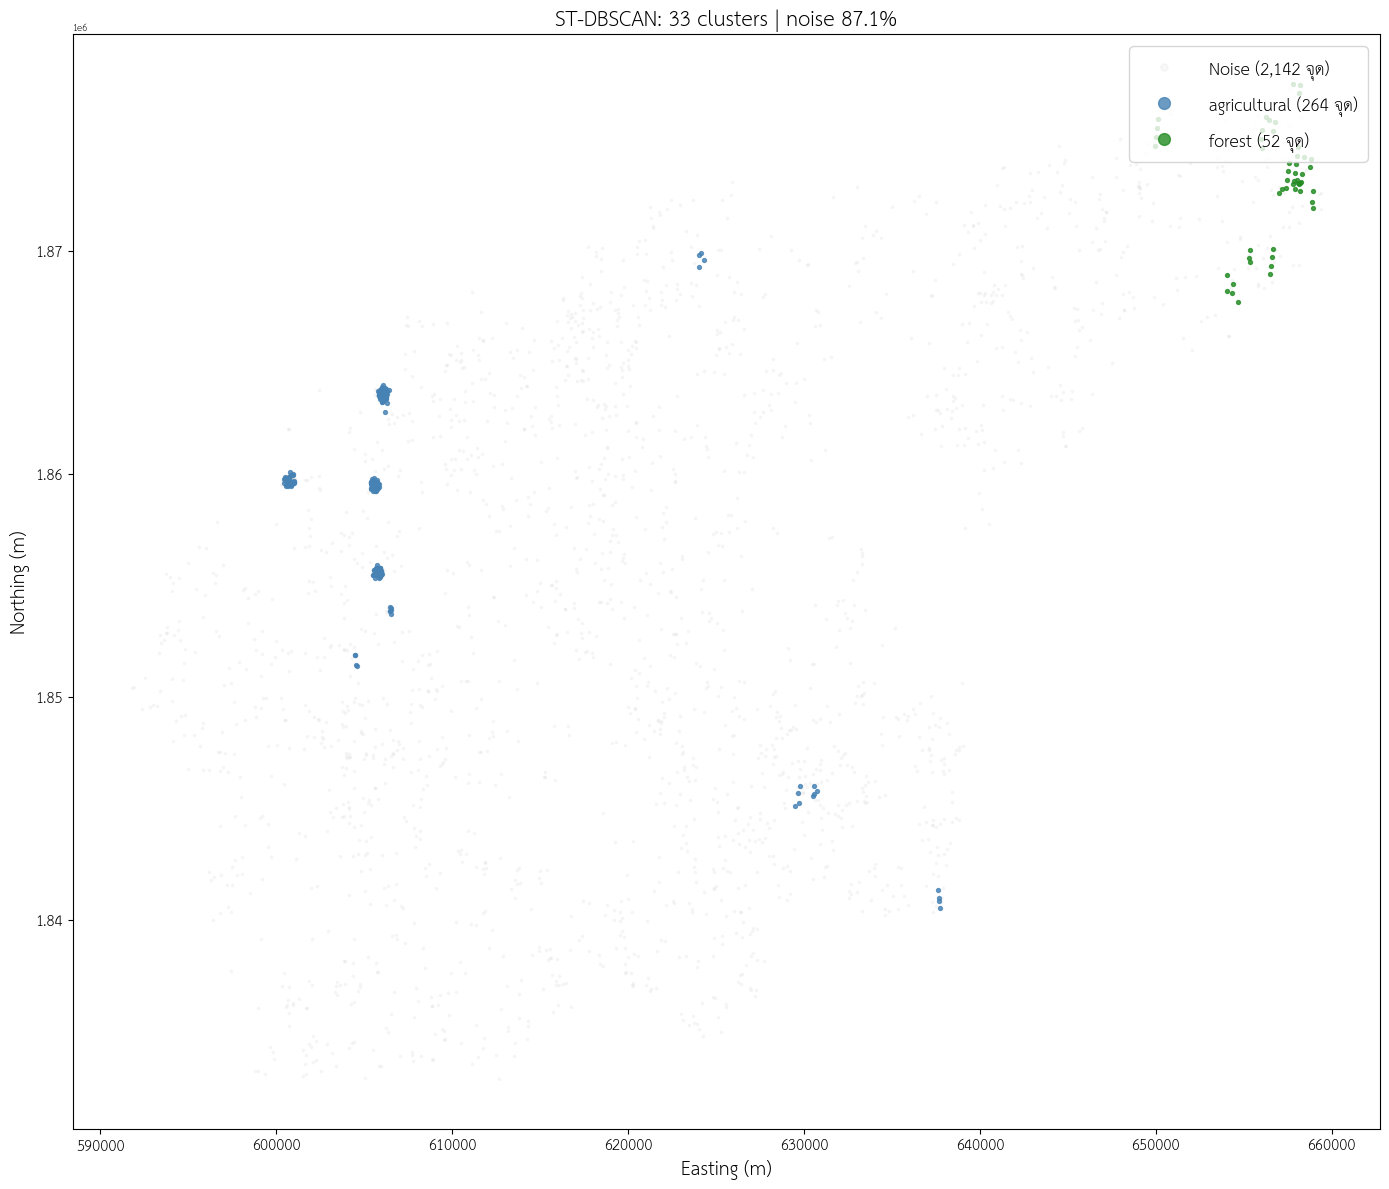

✓ บันทึกกราฟ cluster map สำเร็จ


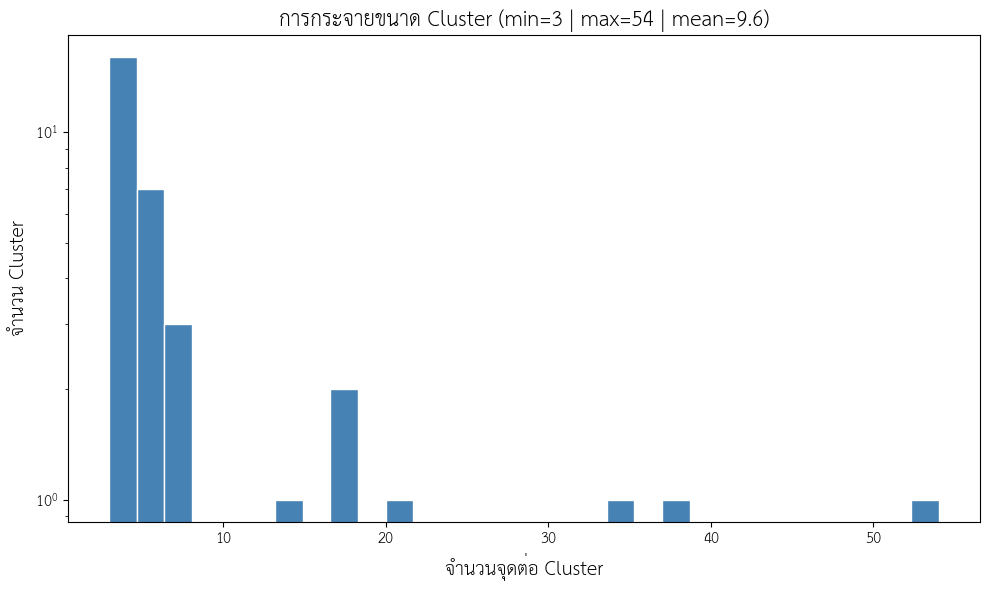

✓ บันทึกกราฟการกระจาย cluster สำเร็จ


In [22]:
# CELL 7a — Visualize Hotspot แยกตาม Cluster
gdf_cluster = gdf[gdf['cluster_id'] != -1]
gdf_noise   = gdf[gdf['cluster_id'] == -1]

fig, ax = plt.subplots(figsize=(14, 12))
# noise
ax.scatter(gdf_noise['x_utm'], gdf_noise['y_utm'],
           s=3, alpha=0.15, color='lightgray', label=f'Noise ({len(gdf_noise):,} จุด)')
# cluster แยกตาม fire_type สีต่างกัน
# สีเฉพาะประเภทที่นำเข้าวิเคราะห์ (ตาม params) — ไม่พล็อต 'other' ที่เป็น noise ทั้งหมด
palette = {'agricultural': 'steelblue', 'forest': 'forestgreen'}
for ft in params:
    sub = gdf_cluster[gdf_cluster['fire_type'] == ft]
    ax.scatter(sub['x_utm'], sub['y_utm'],
               s=8, alpha=0.8, color=palette.get(ft, 'coral'),
               label=f'{ft} ({len(sub):,} จุด)')
ax.set_title(f'ST-DBSCAN: {n_clusters} clusters | noise {noise_pct:.1f}%', fontsize=22)
ax.set_xlabel('Easting (m)', fontsize=20)
ax.set_ylabel('Northing (m)', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.legend(loc='upper right', markerscale=3, fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase2_clusters_map_DBCV.png'), dpi=200)
plt.show()
print('✓ บันทึกกราฟ cluster map สำเร็จ')

# CELL 7b — การกระจายขนาด Cluster
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(cluster_sizes.values, bins=30, color='steelblue', edgecolor='white')
ax.set_title(f'การกระจายขนาด Cluster (min={cluster_sizes.min()} | max={cluster_sizes.max()} | mean={cluster_sizes.mean():.1f})', fontsize=22)
ax.set_xlabel('จำนวนจุดต่อ Cluster', fontsize=20)
ax.set_ylabel('จำนวน Cluster', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase2_cluster_dist_DBCV.png'), dpi=150)
plt.show()
print('✓ บันทึกกราฟการกระจาย cluster สำเร็จ')

In [23]:
# CELL 8 — วิเคราะห์ Cluster
print('จำนวน cluster ต่อ burn_season:')
burn_cluster = gdf[gdf['cluster_id'] != -1].groupby('burn_season')['cluster_id'].nunique()
print(burn_cluster.to_string())

print('\nจำนวนจุดใน cluster ต่ออำเภอ:')
amphoe_cluster = gdf[gdf['cluster_id'] != -1]['amphoe'].value_counts()
print(amphoe_cluster.to_string())

print('\nfire_type ใน cluster vs noise:')
for grp, mask in [('cluster', gdf['cluster_id'] != -1), ('noise', gdf['cluster_id'] == -1)]:
    ft = gdf[mask]['fire_type'].value_counts()
    print(f'  {grp}:')
    print(ft.to_string())

# Phase 1 ไม่ได้สร้าง fire_type_detail — ใช้ land_use_type แทนถ้ามี
detail_col = 'fire_type_detail' if 'fire_type_detail' in gdf.columns else (
             'land_use_type' if 'land_use_type' in gdf.columns else None)
if detail_col:
    print(f'\n{detail_col} ใน cluster vs noise (Top 10):')
    for grp, mask in [('cluster', gdf['cluster_id'] != -1), ('noise', gdf['cluster_id'] == -1)]:
        ft = gdf[mask][detail_col].value_counts().head(10)
        print(f'  {grp}:')
        print(ft.to_string())
else:
    print('\n(ไม่มี fire_type_detail / land_use_type — ข้ามส่วนนี้)')

จำนวน cluster ต่อ burn_season:
burn_season
early_late_burn    16
off_season          3
peak_burn          22
pre_season          7

จำนวนจุดใน cluster ต่ออำเภอ:
amphoe
Bang Rakam            248
Mueang Phitsanulok     68

fire_type ใน cluster vs noise:
  cluster:
fire_type
agricultural    264
forest           52
  noise:
fire_type
agricultural    1844
other            221
forest            77

fire_type_detail ใน cluster vs noise (Top 10):
  cluster:
fire_type_detail
agri_paddy          210
forest_deciduous     52
agri_orchard         31
agri_mixed            8
agri_abandoned        7
agri_sugarcane        5
agri_cassava          2
agri_corn             1
  noise:
fire_type_detail
agri_paddy          1369
agri_sugarcane       374
other                221
forest_deciduous      77
agri_perennial        23
agri_orchard          20
agri_corn             19
agri_cassava          14
agri_mixed            11
agri_abandoned         9


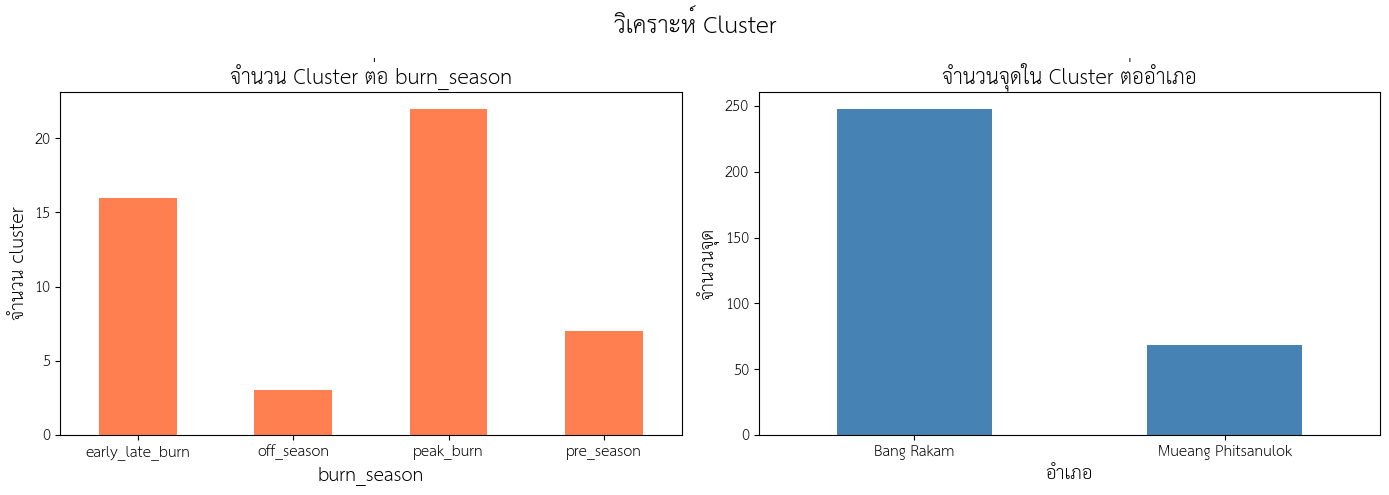

✓ บันทึกกราฟวิเคราะห์สำเร็จ


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('วิเคราะห์ Cluster', fontsize=25)

burn_cluster.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('จำนวน Cluster ต่อ burn_season', fontsize=22)
axes[0].set_xlabel('burn_season', fontsize=20)
axes[0].set_ylabel('จำนวน cluster', fontsize=20)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].tick_params(axis='x', rotation=0)

amphoe_cluster.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('จำนวนจุดใน Cluster ต่ออำเภอ', fontsize=22)
axes[1].set_xlabel('อำเภอ', fontsize=20)
axes[1].set_ylabel('จำนวนจุด', fontsize=20)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase2_cluster_analysis_DBCV.png'), dpi=150)
plt.show()
print('✓ บันทึกกราฟวิเคราะห์สำเร็จ')

In [26]:
# ── Export ────────────────────────────────────────────────────────────────
# mode='w' บังคับเขียนทับไฟล์เก่า (ป้องกันข้อมูลซ้อน)
gdf.to_file(PATH_OUTPUT, driver='GPKG', mode='w')
print(f"✓ Export สำเร็จ: {PATH_OUTPUT}")


✓ Export สำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final\hotspot_clustered_final.gpkg


In [27]:
# --- CHECKPOINT FINAL ---
print('\n[CHECKPOINT FINAL] ตรวจสอบก่อนส่งต่อ Phase 3')
assert os.path.exists(PATH_OUTPUT),           '✗ ไม่พบไฟล์ output'
gdf_verify = gpd.read_file(PATH_OUTPUT)
assert len(gdf_verify) == len(gdf),           '✗ จำนวนแถวไม่ตรง'
assert 'cluster_id' in gdf_verify.columns,    '✗ ไม่มี cluster_id'
assert gdf_verify['cluster_id'].notna().all(), '✗ cluster_id มี null'

print(f'✓ บันทึกสำเร็จ: {PATH_OUTPUT}')
print(f'✓ จำนวนแถว: {len(gdf_verify):,}')
print(f'✓ cluster_id: {gdf_verify["cluster_id"].min()} ถึง {gdf_verify["cluster_id"].max()}')
print(f'✓ CRS: {gdf_verify.crs}')

print(f"\n{'='*60}")
print(f'สรุปผล Phase 2 (ST-DBSCAN):')
for r in results_summary:
    print(f'  {r["fire_type"]}: cluster={r["n_cluster"]} | noise={r["noise_pct"]:.1f}% | DBCV={r["dbcv"]:.4f}')
print(f'รวม: {n_clusters} cluster | noise={noise_pct:.1f}%')
print(f"{'='*60}")
print('Phase 2 เสร็จสมบูรณ์ พร้อมเข้า Phase 3')


[CHECKPOINT FINAL] ตรวจสอบก่อนส่งต่อ Phase 3
✓ บันทึกสำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 2 Final\hotspot_clustered_final.gpkg
✓ จำนวนแถว: 2,458
✓ cluster_id: -1 ถึง 32
✓ CRS: EPSG:32647

สรุปผล Phase 2 (ST-DBSCAN):
  agricultural: cluster=23 | noise=87.5% | DBCV=0.6679
  forest: cluster=10 | noise=59.7% | DBCV=0.6406
รวม: 33 cluster | noise=87.1%
Phase 2 เสร็จสมบูรณ์ พร้อมเข้า Phase 3
